# CS-671, Fall 2025 - HW 1, Q2

## StarterCode Setup

### Importing Libraries

In [9]:
import numpy as np
from numpy.linalg import norm
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

### Loading Dataset, Splitting Data into Train and Test sets

In [10]:
bcd = load_breast_cancer()
X = bcd.data
y = bcd.target
y = 1 - y



# Split the dataset with a fixed random seed (random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

# so it seems we have 455 samples in the training set and 114 in the test set


(455, 30) (114, 30) (455,) (114,)


## Q2 (a): Is accuracy or F1 more appropriate?

Accuracy can be misleading on imbalanced datasets because it is dominated by the majority class. Breast cancer data is moderately imbalanced, and false negatives (predicting benign when malignant) are particularly costly. The F1 score, being the harmonic mean of precision and recall, focuses on performance for the positive class and balances missed positives (FN) and false alarms (FP). Therefore, F1 is more appropriate here.


### Utilities: MinMax scaler, distances, and k-NN (from scratch)
We'll implement:
- A simple `SafeNormalizer` fit on train only, then transform train/test
- Distance metrics: Euclidean, Manhattan, Cosine
- A compact, readable `KNNClassifier` supporting arbitrary distance callables


In [ ]:
# Clean, minimal, well-documented implementations
from typing import Callable, Tuple
    

class SafeNormalizer:
    """ See for normalizing, we can either normalize the columns or the rows. I think it's a good idea to normalize all the columns and than make the rows 
    Fits on training data; transforms with feature-wise min/max.
    Prevents leakage by computing stats only on the training set passed to fit.
    """
    def __init__(self):
        self.data_min_: np.ndarray | None = None
        self.data_max_: np.ndarray | None = None
        self.scale_: np.ndarray | None = None
        self.min_: np.ndarray | None = None

    def fit(self, X: np.ndarray) -> "SafeNormalizer":
        self.data_min_ = X.min(axis=0)
        self.data_max_ = X.max(axis=0)
        denom = (self.data_max_ - self.data_min_)
        # Avoid division by zero for constant features
        denom[denom == 0.0] = 1.0
        self.scale_ = 1.0 / denom
        self.min_ = -self.data_min_ * self.scale_
        return self

    def transform(self, X: np.ndarray) -> np.ndarray:
        assert self.scale_ is not None and self.min_ is not None
        return X * self.scale_ + self.min_

    def fit_transform(self, X: np.ndarray) -> np.ndarray:
        return self.fit(X).transform(X)

# Distance metrics (vectorized over reference set)

def euclidean_distance_matrix(A: np.ndarray, B: np.ndarray) -> np.ndarray:
    """Pairwise Euclidean distances between rows of A (n_a,d) and B (n_b,d)."""
    # ||a-b||^2 = ||a||^2 + ||b||^2 - 2 a.b
    A2 = np.sum(A*A, axis=1, keepdims=True)
    B2 = np.sum(B*B, axis=1, keepdims=True).T
    d2 = A2 + B2 - 2 * (A @ B.T)
    np.maximum(d2, 0.0, out=d2)
    return np.sqrt(d2)

def manhattan_distance_matrix(A: np.ndarray, B: np.ndarray) -> np.ndarray:
    """Pairwise L1 distances."""
    # Broadcast subtraction then sum abs along features
    return np.sum(np.abs(A[:, None, :] - B[None, :, :]), axis=2)

def cosine_distance_matrix(A: np.ndarray, B: np.ndarray) -> np.ndarray:
    """Pairwise cosine distance = 1 - cosine similarity."""
    A_norm = np.linalg.norm(A, axis=1, keepdims=True)
    B_norm = np.linalg.norm(B, axis=1, keepdims=True)
    # Avoid division by zero
    A_norm[A_norm == 0.0] = 1.0
    B_norm[B_norm == 0.0] = 1.0
    sim = (A @ B.T) / (A_norm * B_norm.T)
    # Numerical safety: clamp
    sim = np.clip(sim, -1.0, 1.0)
    return 1.0 - sim

class KNNClassifier:
    """Simple k-NN classifier supporting custom pairwise distance functions.
    Expects y in {0,1}. Predicts majority vote among k nearest neighbors.
    """
    def __init__(self, k: int, distance_fn: Callable[[np.ndarray, np.ndarray], np.ndarray]):
        assert k >= 1
        self.k = k
        self.distance_fn = distance_fn
        self.X_train: np.ndarray | None = None
        self.y_train: np.ndarray | None = None

    def fit(self, X: np.ndarray, y: np.ndarray) -> "KNNClassifier":
        self.X_train = X
        self.y_train = y
        return self

    def predict_proba_positive(self, X: np.ndarray) -> np.ndarray:
        assert self.X_train is not None and self.y_train is not None
        # Compute distances from queries to all training points
        D = self.distance_fn(X, self.X_train)  # shape (n_test, n_train)
        # Indices of k closest neighbors per row
        knn_idx = np.argpartition(D, kth=self.k-1, axis=1)[:, :self.k]
        # For exact ordering among top-k (optional):
        # row-wise sort of the top-k slice
        row_indices = np.arange(X.shape[0])[:, None]
        knn_sorted = knn_idx[row_indices, np.argsort(D[row_indices, knn_idx])]
        # Compute fraction of positive labels among top-k
        pos_counts = np.sum(self.y_train[knn_sorted], axis=1)
        return pos_counts / self.k

    def predict(self, X: np.ndarray, threshold: float = 0.5) -> np.ndarray:
        p = self.predict_proba_positive(X)
        return (p >= threshold).astype(int)

# Metrics

def precision_recall_f1(y_true: np.ndarray, y_pred: np.ndarray) -> Tuple[float, float, float]:
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    if precision + recall == 0:
        f1 = 0.0
    else:
        f1 = 2 * precision * recall / (precision + recall)
    return precision, recall, f1


### Q2 (b): Evaluate k=31 with Euclidean distance (normalized)
We scale with train-only MinMax, fit k-NN, and compute F1 on the held-out test set.

Q2 (b): Implement a k-NN algorithm from scratch to classify the dataset. Use `k = 31` and the `euclidean` distance, and __make sure to normalize the data__. Report your model’s F1 score on the test set.


In [ ]:
# Normalize train and test using train-only stats, then evaluate k=31
scaler = SafeNormalizer().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn31 = KNNClassifier(k=31, distance_fn=euclidean_distance_matrix).fit(X_train_scaled, y_train)
y_pred_test = knn31.predict(X_test_scaled)
pre, rec, f1 = precision_recall_f1(y_test, y_pred_test)
print(f"k=31 Euclidean | Precision={pre:.4f} Recall={rec:.4f} F1={f1:.4f}")


k=31 Euclidean | Precision=1.0000 Recall=0.8810 F1=0.9367


### Q2 (c): 5-fold cross-validation over k and distance metrics
We implement CV from scratch, using only NumPy. For each distance, we sweep k and record mean F1 across folds. Then we plot F1 vs k and select the best pair.


Q2 (c): Use cross-validation with 5 folds and the F1 score to tune the value of k and the distance function used (possible distance functions to use could be Euclidean distance, Manhattan distance, or cosine similarity). Make sure to use at least five values of k between 1 and 63, and try at least two distance functions. For each distance function, show a plot where the x-axis depicts the value of k and the y-axis depicts the average F1 score for that value of k during cross-validation. Which pair of parameters performed the best? Note: You may find the array split method from NumPy helpful when implementing cross-validation.

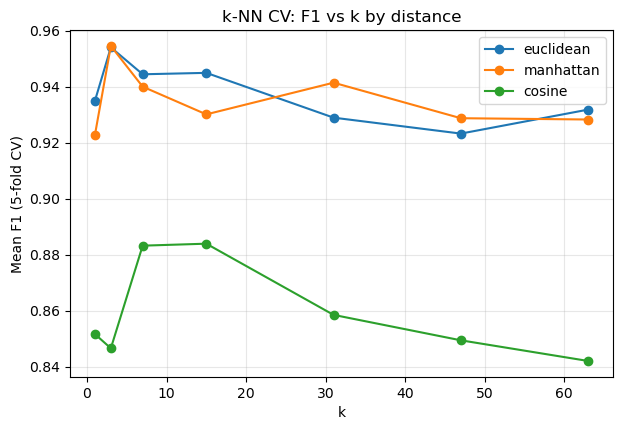

Best by CV: distance=manhattan, k=3, mean F1=0.9546


In [ ]:
# 5-fold CV implementation (train set only) and plotting
from numpy import array_split

def kfold_indices(n: int, n_splits: int = 5, rng: int | None = 42):
    idx = np.arange(n)
    if rng is not None:
        rs = np.random.RandomState(rng)
        rs.shuffle(idx)
    folds = array_split(idx, n_splits)
    for i in range(n_splits):
        val_idx = folds[i]
        train_idx = np.concatenate([folds[j] for j in range(n_splits) if j != i])
        yield train_idx, val_idx

k_values = [1, 3, 7, 15, 31, 47, 63]
distance_fns = {
    "euclidean": euclidean_distance_matrix,
    "manhattan": manhattan_distance_matrix,
    "cosine": cosine_distance_matrix,
}

# Normalize once using full train stats? To avoid leakage, each fold fits scaler on fold-train only.
def cv_mean_f1_for_distance(distance_name: str, distance_fn: Callable[[np.ndarray, np.ndarray], np.ndarray]) -> tuple[list[int], list[float]]:
    mean_f1_per_k: list[float] = []
    for k in k_values:
        f1_scores: list[float] = []
        for tr_idx, va_idx in kfold_indices(len(X_train), n_splits=5, rng=42):
            X_tr, X_va = X_train[tr_idx], X_train[va_idx]
            y_tr, y_va = y_train[tr_idx], y_train[va_idx]
            # Fit scaler on fold-train only
            scaler_cv = SafeNormalizer().fit(X_tr)
            X_tr_s = scaler_cv.transform(X_tr)
            X_va_s = scaler_cv.transform(X_va)
            # Train and eval
            model = KNNClassifier(k=k, distance_fn=distance_fn).fit(X_tr_s, y_tr)
            y_va_pred = model.predict(X_va_s)
            _, _, f1_va = precision_recall_f1(y_va, y_va_pred)
            f1_scores.append(f1_va)
        mean_f1_per_k.append(float(np.mean(f1_scores)))
    return k_values, mean_f1_per_k

results = {}
plt.figure(figsize=(7,4.5))
for name, fn in distance_fns.items():
    ks, mean_f1s = cv_mean_f1_for_distance(name, fn)
    results[name] = {"k": ks, "mean_f1": mean_f1s}
    plt.plot(ks, mean_f1s, marker='o', label=name)
plt.xlabel('k')
plt.ylabel('Mean F1 (5-fold CV)')
plt.title('k-NN CV: F1 vs k by distance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Find best pair
best_name, best_k, best_score = None, None, -1.0
for name, res in results.items():
    for k, s in zip(res["k"], res["mean_f1"]):
        if s > best_score:
            best_name, best_k, best_score = name, k, s
print(f"Best by CV: distance={best_name}, k={best_k}, mean F1={best_score:.4f}")


### Q2 (d): Train with best params (from CV) and evaluate on test
We refit scaler on all training data, train k-NN with best (distance, k), and report test F1.

Q2 (d): Using the best parameters determined in part (c), report the performance of a k-NN classifier on the test set. Compare this to your model in part (b). Is it as you expected?

In [ ]:
# Refit scaler on full training set and evaluate best model on test
# Reuse `results` and `best_name`, `best_k` computed above.
best_distance_fn = distance_fns[best_name]

scaler_best = SafeNormalizer().fit(X_train)
X_train_best = scaler_best.transform(X_train)
X_test_best = scaler_best.transform(X_test)

best_model = KNNClassifier(k=best_k, distance_fn=best_distance_fn).fit(X_train_best, y_train)
y_test_pred_best = best_model.predict(X_test_best)
pre_b, rec_b, f1_b = precision_recall_f1(y_test, y_test_pred_best)
print(f"Best params on test | distance={best_name}, k={best_k} -> Precision={pre_b:.4f} Recall={rec_b:.4f} F1={f1_b:.4f}")

# Brief comparison with part (b)
print("Compared to fixed k=31 Euclidean above.")


Best params on test | distance=manhattan, k=3 -> Precision=1.0000 Recall=0.9286 F1=0.9630
Compared to fixed k=31 Euclidean above.


### Q2 (e): ROC curve and AUC (from scratch)
We compute positive-class vote fractions, sweep thresholds, compute (FPR, TPR), plot ROC, and calculate AUC using trapezoidal rule. The grouping-by-vote approach is used for efficiency.

Q2 (e -> i): Using the test dataset and the same parameters as part (c), plot the ROC curve of your classifier as points connected by lines. You may implement the ROC curve computation using either of the two methods discussed in the HW PDF

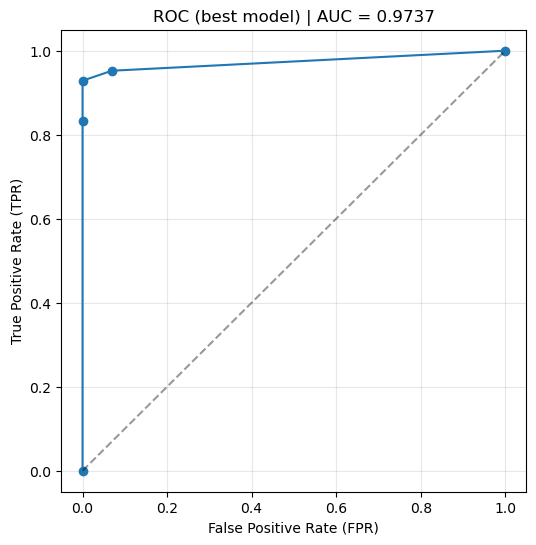

AUC (from scratch) = 0.973710


In [15]:
# Compute ROC points using the best model's parameters
# We reuse `best_model` which exposes per-point positive fraction via predict_proba_positive
proba_pos = best_model.predict_proba_positive(X_test_best)

# Thresholds: for k-NN with integer vote counts, the classification threshold over probability
# effectively steps at i/k for i in {0..k}. We'll sweep from >k to >0 using these breakpoints.
thresholds = np.linspace(1.0 + 1e-9, -1e-9, best_k + 2)  # include >1 down to >=0 smoothly for plotting

# Compute TPR and FPR for each threshold

def roc_points(y_true: np.ndarray, scores: np.ndarray, thresholds: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    tprs, fprs = [], []
    P = np.sum(y_true == 1)
    N = np.sum(y_true == 0)
    for t in thresholds:
        y_pred = (scores >= t).astype(int)
        tp = np.sum((y_true == 1) & (y_pred == 1))
        fp = np.sum((y_true == 0) & (y_pred == 1))
        tpr = tp / P if P > 0 else 0.0
        fpr = fp / N if N > 0 else 0.0
        tprs.append(tpr)
        fprs.append(fpr)
    return np.array(fprs), np.array(tprs)

fpr, tpr = roc_points(y_test, proba_pos, thresholds)

# Sort by FPR ascending to integrate consistently
order = np.argsort(fpr)
fpr_sorted, tpr_sorted = fpr[order], tpr[order]

# AUC via trapezoidal rule (from scratch)
def auc_trapezoid(x: np.ndarray, y: np.ndarray) -> float:
    area = 0.0
    for i in range(1, len(x)):
        dx = x[i] - x[i-1]
        area += dx * (y[i] + y[i-1]) / 2.0
    return float(area)

auc = auc_trapezoid(fpr_sorted, tpr_sorted)

plt.figure(figsize=(6,6))
plt.plot(fpr_sorted, tpr_sorted, marker='o', lw=1.5)
plt.plot([0,1], [0,1], 'k--', alpha=0.4)
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title(f'ROC (best model) | AUC = {auc:.4f}')
plt.grid(True, alpha=0.3)
plt.show()

print(f"AUC (from scratch) = {auc:.6f}")
